# Wine Quality Classification - KNN
**Gray Interface '26 | Task 3 - Part 1**

Dataset: Wine Quality (Red and White)

## Importing the Dependencies

In [ ]:
!pip install kagglehub seaborn --quiet


In [ ]:
import kagglehub
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


## Loading the Dataset

In [ ]:
# Downloading the wine quality dataset from Kaggle
path = kagglehub.dataset_download("sinadehestani/wine-quality-red-and-white")
print(os.listdir(path))

df = pd.read_csv(os.path.join(path, "wine_quality_merged.csv"))
print("Dataset Shape:", df.shape)
df.head()


100%|██████████| 100k/100k [00:00<00:00, 23.3MB/s]

Extracting files...
['wine_quality_merged.csv']
Dataset Shape: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


## Basic Dataset Information

In [ ]:
# Column names and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [ ]:
# Checking for missing values
df.isnull().sum()


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
# Statistical summary of numerical columns
df.describe()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [ ]:
# Class distribution of wine quality
print(df['quality'].value_counts().sort_index())
print()
print(df['type'].value_counts())


quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

type
white    4898
red      1599
Name: count, dtype: int64


## Exploratory Data Analysis

/tmp/ipykernel_2001/2988144067.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='viridis')


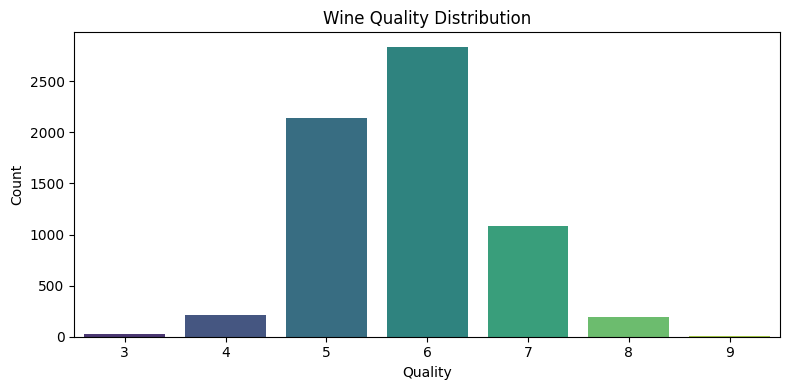

In [ ]:
# Quality count plot
plt.figure(figsize=(8, 4))
sns.countplot(x='quality', data=df, palette='viridis')
plt.title('Wine Quality Distribution')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


/tmp/ipykernel_2001/2136948506.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='Set2')


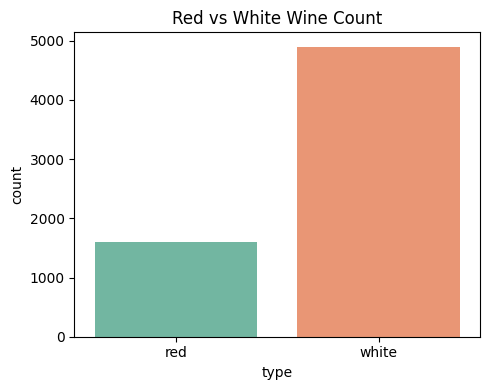

In [ ]:
# Red vs White wines
plt.figure(figsize=(5, 4))
sns.countplot(x='type', data=df, palette='Set2')
plt.title('Red vs White Wine Count')
plt.tight_layout()
plt.show()


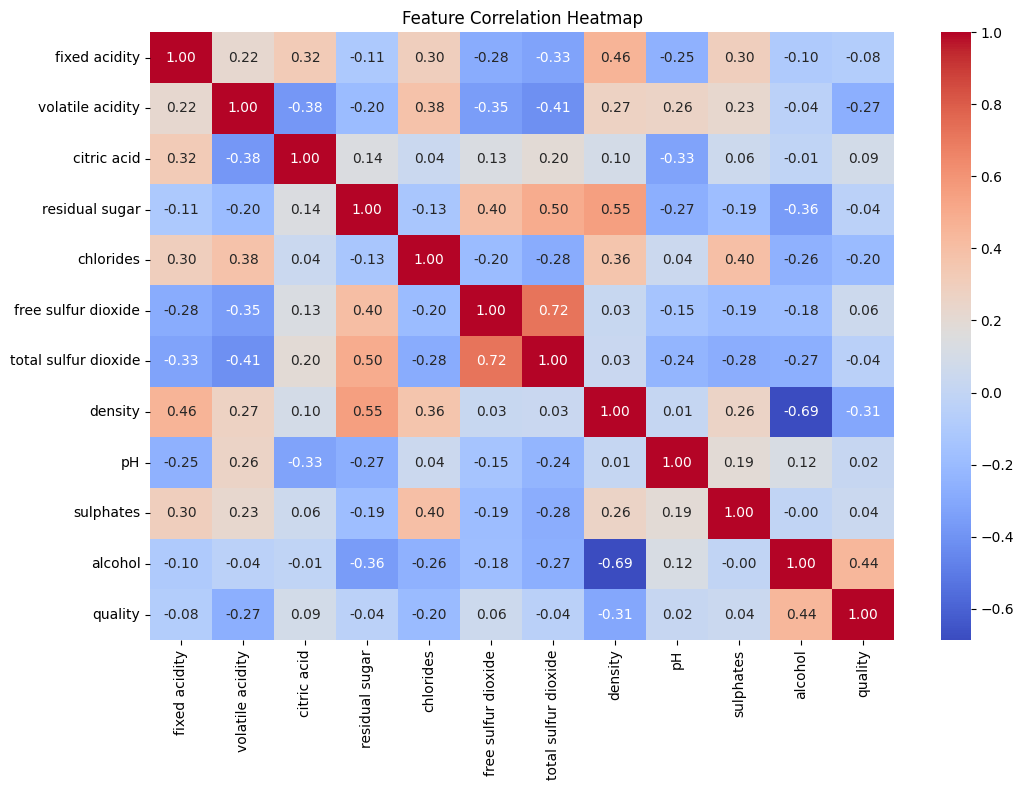

In [ ]:
# Correlation heatmap of features
plt.figure(figsize=(11, 8))
sns.heatmap(df.drop(columns=['type']).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


## Observations so far
- No missing values in this dataset
- Quality ranges from 3 to 9, and most wines are quality 5 or 6 (imbalanced)
- Dataset includes both red and white wines
- Some features like density and residual sugar are correlated


## Preprocessing

In [ ]:
# Encoding wine type (red/white) into numbers
le = LabelEncoder()
df['type_enc'] = le.fit_transform(df['type'])

# Features (X) and target (Y)
X = df.drop(columns=['quality', 'type'])
Y = df['quality']

print("Feature columns:", X.columns.tolist())
print("X shape:", X.shape)
print("Y shape:", Y.shape)


Feature columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'type_enc']
X shape: (6497, 12)
Y shape: (6497,)


In [ ]:
# Train-test split (80-20), stratified so class ratios stay similar
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)
print(X_train.shape, X_test.shape)


(5197, 12) (1300, 12)


## Comparing Feature Scaling Techniques

In [ ]:
# Preparing three versions of the data:
# 1) No Scaling
# 2) StandardScaler (mean=0, std=1)
# 3) MinMaxScaler (values between 0 and 1)

scalers = {
    'No Scaling': None,
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler()
}

scaled_data = {}
for name, scaler in scalers.items():
    if scaler is None:
        scaled_data[name] = (X_train.values, X_test.values)
    else:
        scaled_data[name] = (scaler.fit_transform(X_train), scaler.transform(X_test))
    print(name, "ready")


No Scaling ready
StandardScaler ready
MinMaxScaler ready


In [ ]:
# Quick comparison using default KNN (k=5, euclidean, uniform)
print("Scaling comparison with K=5 (Euclidean, Uniform):\n")
for name, (xtr, xts) in scaled_data.items():
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(xtr, Y_train)
    pred = model.predict(xts)
    acc = accuracy_score(Y_test, pred)
    f1 = f1_score(Y_test, pred, average='weighted')
    print(f"{name:16s} -> Accuracy: {acc:.4f} | F1: {f1:.4f}")


Scaling comparison with K=5 (Euclidean, Uniform):

No Scaling       -> Accuracy: 0.4854 | F1: 0.4732
StandardScaler   -> Accuracy: 0.5585 | F1: 0.5489
MinMaxScaler     -> Accuracy: 0.5562 | F1: 0.5480


KNN uses distance, so scaling matters a lot.
Features like total sulfur dioxide have much larger values than pH,
so without scaling those features dominate the distance calculation.
StandardScaler usually works well here.


## Experimenting with Different K Values

In [ ]:
# Using StandardScaler for the rest of the experiments
X_train_sc, X_test_sc = scaled_data['StandardScaler']

k_values = list(range(1, 31))
acc_scores = []
f1_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_sc, Y_train)
    pred = model.predict(X_test_sc)
    acc_scores.append(accuracy_score(Y_test, pred))
    f1_scores.append(f1_score(Y_test, pred, average='weighted'))

best_k = k_values[int(np.argmax(f1_scores))]
print(f"Best K by F1: {best_k} (F1={max(f1_scores):.4f}, Acc={acc_scores[k_values.index(best_k)]:.4f})")


Best K by F1: 1 (F1=0.6263, Acc=0.6277)


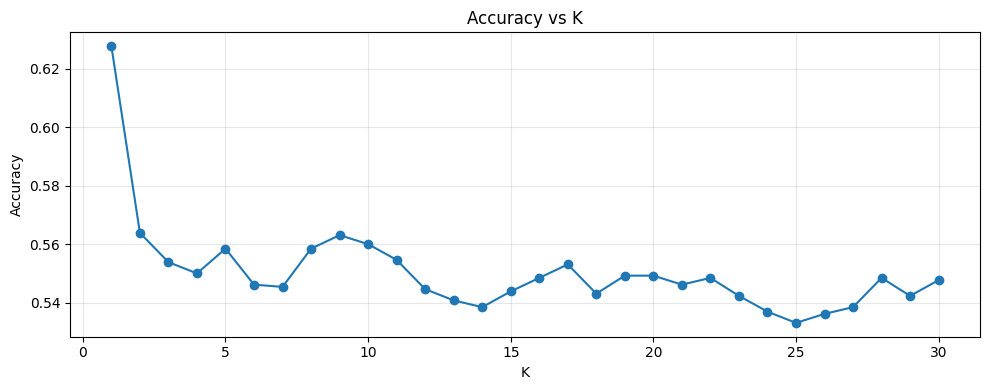

In [ ]:
# Accuracy vs K
plt.figure(figsize=(10, 4))
plt.plot(k_values, acc_scores, marker='o')
plt.title('Accuracy vs K')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


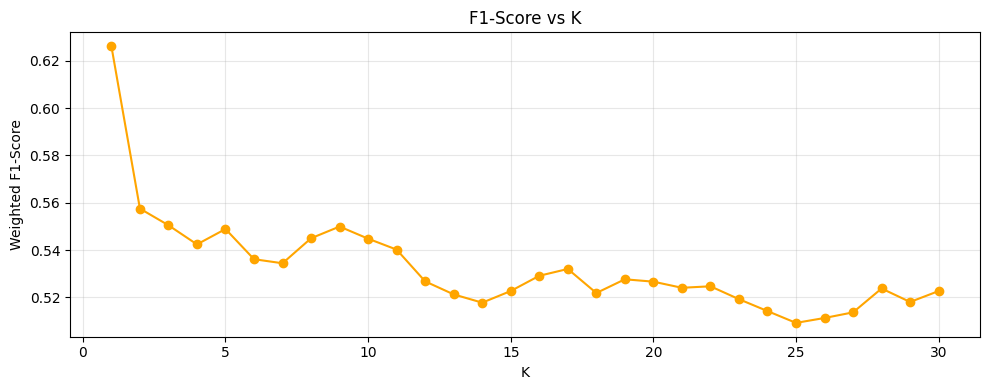

In [ ]:
# F1-Score vs K
plt.figure(figsize=(10, 4))
plt.plot(k_values, f1_scores, marker='o', color='orange')
plt.title('F1-Score vs K')
plt.xlabel('K')
plt.ylabel('Weighted F1-Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Comparing Distance Metrics

In [ ]:
# Euclidean, Manhattan, Minkowski with best K
metrics = ['euclidean', 'manhattan', 'minkowski']

print(f"Distance metric comparison (K={best_k}, Uniform weights):\n")
for metric in metrics:
    model = KNeighborsClassifier(n_neighbors=best_k, metric=metric, p=2)
    model.fit(X_train_sc, Y_train)
    pred = model.predict(X_test_sc)
    acc = accuracy_score(Y_test, pred)
    f1 = f1_score(Y_test, pred, average='weighted')
    print(f"{metric:12s} -> Accuracy: {acc:.4f} | F1: {f1:.4f}")


Distance metric comparison (K=1, Uniform weights):

euclidean    -> Accuracy: 0.6277 | F1: 0.6263
manhattan    -> Accuracy: 0.6477 | F1: 0.6468
minkowski    -> Accuracy: 0.6277 | F1: 0.6263


## Comparing Weighting Methods

In [ ]:
# Uniform = all neighbors equal vote
# Distance = closer neighbors get more weight
weights_list = ['uniform', 'distance']

print(f"Weighting comparison (K={best_k}, Euclidean):\n")
for w in weights_list:
    model = KNeighborsClassifier(n_neighbors=best_k, weights=w, metric='euclidean')
    model.fit(X_train_sc, Y_train)
    pred = model.predict(X_test_sc)
    acc = accuracy_score(Y_test, pred)
    f1 = f1_score(Y_test, pred, average='weighted')
    print(f"{w:10s} -> Accuracy: {acc:.4f} | F1: {f1:.4f}")


Weighting comparison (K=1, Euclidean):

uniform    -> Accuracy: 0.6277 | F1: 0.6263
distance   -> Accuracy: 0.6277 | F1: 0.6263


## Final Combined Comparison

In [ ]:
# Trying a few strong combinations together
results = []
for scaler_name in ['No Scaling', 'StandardScaler', 'MinMaxScaler']:
    xtr, xts = scaled_data[scaler_name]
    for k in [3, 5, 7, 11, best_k]:
        for metric in ['euclidean', 'manhattan']:
            for w in ['uniform', 'distance']:
                model = KNeighborsClassifier(n_neighbors=k, metric=metric, weights=w)
                model.fit(xtr, Y_train)
                pred = model.predict(xts)
                results.append({
                    'Scaler': scaler_name,
                    'K': k,
                    'Metric': metric,
                    'Weights': w,
                    'Accuracy': accuracy_score(Y_test, pred),
                    'F1': f1_score(Y_test, pred, average='weighted')
                })

results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
results_df.head(10)


,Scaler,K,Metric,Weights,Accuracy,F1
55,MinMaxScaler,11,manhattan,distance,0.666154,0.656370
27,StandardScaler,5,manhattan,distance,0.661538,0.656226
31,StandardScaler,7,manhattan,distance,0.662308,0.655016
33,StandardScaler,11,euclidean,distance,0.662308,0.653267
23,StandardScaler,3,manhattan,distance,0.656154,0.653262
47,MinMaxScaler,5,manhattan,distance,0.656923,0.650710
49,MinMaxScaler,7,euclidean,distance,0.656923,0.649208
25,StandardScaler,5,euclidean,distance,0.653846,0.647840
41,MinMaxScaler,3,euclidean,distance,0.650769,0.647684
38,StandardScaler,1,manhattan,uniform,0.647692,0.646791


In [ ]:
# Best combination from the table above
best_row = results_df.iloc[0]
print("Best combination:")
print(best_row)

xtr, xts = scaled_data[best_row['Scaler']]
best_model = KNeighborsClassifier(
    n_neighbors=int(best_row['K']),
    metric=best_row['Metric'],
    weights=best_row['Weights']
)
best_model.fit(xtr, Y_train)
best_pred = best_model.predict(xts)

print("\nClassification Report:")
print(classification_report(Y_test, best_pred))
print("Confusion Matrix:")
print(confusion_matrix(Y_test, best_pred))


Best combination:
Scaler      MinMaxScaler
K                     11
Metric         manhattan
Weights         distance
Accuracy        0.666154
F1               0.65637
Name: 55, dtype: object

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.57      0.09      0.16        43
           5       0.73      0.71      0.72       428
           6       0.66      0.72      0.69       567
           7       0.57      0.61      0.59       216
           8       0.75      0.38      0.51        39
           9       0.00      0.00      0.00         1

    accuracy                           0.67      1300
   macro avg       0.47      0.36      0.38      1300
weighted avg       0.66      0.67      0.66      1300

Confusion Matrix:
[[  0   0   3   2   1   0   0]
 [  0   4  22  14   3   0   0]
 [  0   2 305 112   9   0   0]
 [  0   1  82 411  69   4   0]
 [  0   0   4  80 131   1   0]
 [  0   0   0 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Key Findings

| # | Finding |
|---|---------|
| 1 | Scaling improves KNN a lot because features are on different scales |
| 2 | StandardScaler / MinMaxScaler both beat No Scaling |
| 3 | Smaller K can overfit; very large K can underfit / smooth too much |
| 4 | Distance weighting often helps when neighbors are mixed |
| 5 | Manhattan can work well on this tabular data, sometimes better than Euclidean |
| 6 | Best setup should be chosen using F1 as well as Accuracy because quality classes are imbalanced |
